# colab5 — Relabeled binary alphabet `{1, 2}` with vanilla SGD

## Hypothesis

The original paper's `for_gen_dense_i` layer computes `relu(w_i * y[i])`. When `y[i] = 0`, the chain rule kills the gradient at the source: `dLoss/dw_i = dLoss/dy_encoded[i] * y[i] = 0`. No optimizer that uses gradients can ever update such a weight — it's a *structural* zero, not a clipping issue. PSO works around this, but the cleaner fix is on the data side: use a binary alphabet that doesn't contain `0`.

## The fix

Relabel the alphabet `{0, 1}` → `{2, 1}`. The model architecture is unchanged, including all frozen analytical weights. The reason this still works:

- `matching_module` only relies on `|a - b| = 1` between the two symbols. For `{1, 2}`, that holds: `|1 - 2| = 1`. Layer-2's `epsilon = 1` threshold then still produces the correct `0/1` substitution cost.
- All other frozen weights (`first_calc_gap_layer`, `input_<i>_<j>` Dense layers, `min_module`, `minimum`) encode **edit-operation costs** (`+1` per insertion/deletion), not character values. They are alphabet-independent.
- The trainable layer becomes:
  - `y[i] = 1` → `relu(w_i * 1) = w_i`, must equal 1 → `w_i = 1` (constrained, gradient factor = 1)
  - `y[i] = 2` → `relu(w_i * 2) = 2*w_i`, must equal 2 → `w_i = 1` (constrained, gradient factor = 2)

Both cases pin `w_i` to 1 *and* both have a nonzero gradient factor. The flat plane of degenerate global minima collapses to a single point, and vanilla SGD should converge from any random initialization.

## Setup

In [1]:
import os
!rm -rf /content/thesis-edit-distance-nn

!git clone https://github.com/katzemelli/thesis-edit-distance-nn.git

os.chdir('/content/thesis-edit-distance-nn')

!ls sampledata/

Cloning into 'thesis-edit-distance-nn'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 100 (delta 56), reused 51 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 558.23 KiB | 3.85 MiB/s, done.
Resolving deltas: 100% (56/56), done.
desired_length_2_levenshtein_2.csv
desired_length_2_levenshtein_3.csv
desired_length_2_levenshtein.csv
desired_length_2_levenshtein_relabel_11.csv
desired_length_2_levenshtein_relabel_21.csv
desired_length_5_levenshtein_relabel_21211.csv
predtime_length_10_2_levenshtein.csv
predtime_length_5_4_levenshtein.csv
predtime_length_5_levenshtein.csv


In [2]:
!pip install tensorflow ml_dtypes --upgrade

In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
import random
import time
import os
import math
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Activation, Input, add, Lambda, Reshape, concatenate, Flatten

## Architecture (identical to original paper / colab4)

In [5]:
def transform_seqs_to_input(seqA, seqB):
    matching_pairs = []
    input_length_x = 0

    matching_pairs.append([int(seqA[0]), int(seqB[0])])
    if len(seqA) == 1 and len(seqB) == 1:
        return matching_pairs
    else:
        input_length_x = len(seqA)
        match_layers_i = (input_length_x * 2) - 1

    start_i = 1
    end_i = 2

    for l in range(match_layers_i):
        if l < input_length_x - 1:
            i, j = [*reversed(range(0, end_i))], [*range(0, end_i)]
            for n in range(len(i)):
                if j[n] < len(seqB):
                    pair = [int(seqA[i[n]]), int(seqB[j[n]])]
                    matching_pairs.append(pair)
            end_i += 1
        else:
            i, j = [*reversed(range(start_i, input_length_x))], [*range(start_i, input_length_x)]
            for n in range(len(i)):
                if j[n] < len(seqB):
                    pair = [int(seqA[i[n]]), int(seqB[j[n]])]
                    matching_pairs.append(pair)
            start_i += 1
            if start_i > len(seqB):
                break

    return matching_pairs


def transform_input_for_generate(input):
    x = []
    y = []
    for pair in input:
        x.append(pair[0])
        y.append(pair[1])
    return [x, y]

In [6]:
def matching_module():
    epsilon = 1

    model = Sequential()
    model.add(Dense(units=2, activation='relu', use_bias=True, input_shape=(2,)))
    model.add(Dense(units=2, activation='relu', use_bias=True))
    model.add(Dense(units=1, activation='relu', use_bias=True))

    w1 = model.layers[0].get_weights()
    w1[0][0][0], w1[0][0][1] = 1.0, -1.0
    w1[0][1][0], w1[0][1][1] = -1.0, 1.0
    w1[1][0], w1[1][1] = 0, 0
    w2 = model.layers[1].get_weights()
    w2[0][0][0], w2[0][0][1] = 1.0, 1.0
    w2[0][1][0], w2[0][1][1] = 1.0, 1.0
    w2[1][0], w2[1][1] = epsilon, -1 * epsilon
    w3 = model.layers[2].get_weights()
    w3[0][0][0], w3[0][1][0] = (1.0/epsilon), -1.0 * (1.0/epsilon)
    w3[1][0] = -1

    model.layers[0].set_weights(w1)
    model.layers[1].set_weights(w2)
    model.layers[2].set_weights(w3)

    model.trainable = False
    return model

In [7]:
def min_module(i, j, k):
    input = Input(shape=(2,))
    x = Dense(2, activation='relu', use_bias=True)(input)
    combined = concatenate([x, input])

    layer_name = 'result_pixel_' + str(i) + str(j) + '_' + str(k)
    z = Dense(1, activation='relu', use_bias=True, name=layer_name)(combined)
    model = Model(inputs=input, outputs=z)

    w1 = model.layers[1].get_weights()
    w1[0][0], w1[0][1] = [-1.0, 1.0], [1.0, -1.0]
    w2 = model.layers[3].get_weights()
    w2[0][0], w2[0][1], w2[0][2], w2[0][3] = -0.5, -0.5, 0.5, 0.5

    model.layers[1].set_weights(w1)
    model.layers[3].set_weights(w2)

    model.trainable = False
    return model


def minimum(i, j):
    input = Input(shape=(3,))
    comp1_pair = Lambda(lambda x: x[:, :2], output_shape=(2,))(input)
    comp2_input = Lambda(lambda x: x[:, 2:], output_shape=(1,))(input)

    m = min_module(i, j, 1)(comp1_pair)
    comp2_pair = concatenate([comp2_input, m])
    output = min_module(i, j, 2)(comp2_pair)

    model = Model(inputs=input, outputs=output)
    model.trainable = False
    return model

In [8]:
def align_model_for_N(seq_length_x, seq_length_y, matching_pair_number):
    input = Input(shape=(2, matching_pair_number), name='input')

    y = Lambda(lambda t: t[:, 1, :], output_shape=(matching_pair_number,))(input)
    x = Lambda(lambda t: t[:, 0, :], output_shape=(matching_pair_number,))(input)

    out = {}
    start_i = 0
    step = 2
    for i in range(seq_length_y):
        a = start_i
        layername = 'for_gen_dense_' + str(i + 1)
        y_slice = Lambda(lambda t, a=a: t[:, a:a+1], output_shape=(1,))(y)
        z = Dense(1, activation='relu', name=layername, use_bias=False)(y_slice)
        out[layername] = z
        start_i += step
        step += 1

    pair_i = 1
    calc_layer = (seq_length_x * 2) - 1
    test_dict = {}

    y_dense_layer_name = 'for_gen_dense_1'
    densed_y = out[y_dense_layer_name]
    x_char = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(x)

    debug_name = 'matching_debug_1'
    pair_11 = concatenate([x_char, densed_y], name=debug_name)

    ext_gaps = Dense(2, activation='relu', name='first_calc_gap_layer')(pair_11)

    min1 = min_module(1, 1, 1)(ext_gaps)
    matching1 = matching_module()(pair_11)
    combined = concatenate([min1, matching1])
    z = min_module(1, 1, 2)(combined)
    result_pixel_11 = concatenate([ext_gaps, z], name='input_pixel_1_1')

    pair_i = 2

    if seq_length_x == 1 and seq_length_y == 1:
        output = z
        return Model(inputs=input, outputs=output)
    else:
        test_dict['input_pixel_1_1'] = result_pixel_11
        test_dict['result_pixel_1_1'] = z

        comp_i_val, comp_j_val = 1, 2
        start_sentinel, end_sentinel = 1, 2
        unbalance_flag = True

        for calc_layer_i in range(calc_layer):
            if calc_layer_i < seq_length_x - 1:
                comp_i_val, comp_j_val = start_sentinel, end_sentinel
                while comp_i_val <= end_sentinel:
                    if comp_i_val <= seq_length_y:
                        input_layer_name = 'input_' + str(comp_i_val) + '_' + str(comp_j_val)
                        before_input_layer_name = 'before_input_' + str(comp_i_val) + '_' + str(comp_j_val)

                        c = pair_i
                        y_i = comp_i_val
                        y_dense_layer_name = 'for_gen_dense_' + str(y_i)
                        densed_y = out[y_dense_layer_name]

                        x_char = Lambda(lambda t, c=c: t[:, c-1:c], output_shape=(1,))(x)

                        debug_name = 'matching_debug_' + str(c)
                        pair = concatenate([x_char, densed_y], name=debug_name)
                        matching = matching_module()(pair)

                        if comp_i_val == 1:
                            previous_input_pixel_name = 'input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)
                            previous_result_pixel_name = 'result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)
                            previous_input = test_dict[previous_input_pixel_name]
                            previous_result = test_dict[previous_result_pixel_name]
                            g = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(previous_input)
                            before_input = concatenate([g, previous_result, matching], name=before_input_layer_name)

                        elif comp_j_val == 1:
                            previous_input_pixel_name = 'input_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)
                            previous_result_pixel_name = 'result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)
                            previous_input = test_dict[previous_input_pixel_name]
                            previous_result = test_dict[previous_result_pixel_name]
                            g = Lambda(lambda t: t[:, 0:1], output_shape=(1,))(previous_input)
                            before_input = concatenate([g, previous_result, matching], name=before_input_layer_name)

                        else:
                            previous_result1 = test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)]
                            previous_result2 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)]
                            previous_result3 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val - 1)]
                            before_input = concatenate([previous_result1, previous_result2, previous_result3, matching], name=before_input_layer_name)

                        input_pixel = Dense(3, activation='relu', name=input_layer_name)(before_input)
                        result_pixel = minimum(comp_i_val, comp_j_val)(input_pixel)

                        test_dict['input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = input_pixel
                        test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = result_pixel

                        if unbalance_flag:
                            unbalance_flag = False

                    comp_i_val += 1
                    comp_j_val -= 1
                    pair_i += 1
                    if unbalance_flag:
                        pair_i -= 1
                    unbalance_flag = True

                if end_sentinel + 1 <= seq_length_x:
                    end_sentinel += 1

            else:
                start_sentinel += 1
                comp_i_val, comp_j_val = start_sentinel, end_sentinel

                while comp_i_val <= end_sentinel:
                    if comp_i_val <= seq_length_y:
                        before_input_layer_name = 'before_input_' + str(comp_i_val) + '_' + str(comp_j_val)
                        input_layer_name = 'input_' + str(comp_i_val) + '_' + str(comp_j_val)

                        c = pair_i
                        y_dense_layer_name = 'for_gen_dense_' + str(comp_i_val)
                        densed_y = out[y_dense_layer_name]

                        x_char = Lambda(lambda t, c=c: t[:, c-1:c], output_shape=(1,))(x)
                        debug_name = 'matching_debug_' + str(c)
                        pair = concatenate([x_char, densed_y], name=debug_name)
                        matching = matching_module()(pair)

                        previous_result1 = test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val - 1)]
                        previous_result2 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val)]
                        previous_result3 = test_dict['result_pixel_' + str(comp_i_val - 1) + '_' + str(comp_j_val - 1)]
                        before_input = concatenate([previous_result1, previous_result2, previous_result3, matching], name=before_input_layer_name)

                        input_pixel = Dense(3, activation='relu', name=input_layer_name)(before_input)
                        result_pixel = minimum(comp_i_val, comp_j_val)(input_pixel)

                        test_dict['input_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = input_pixel
                        test_dict['result_pixel_' + str(comp_i_val) + '_' + str(comp_j_val)] = result_pixel

                        if unbalance_flag:
                            unbalance_flag = False

                    comp_i_val += 1
                    comp_j_val -= 1
                    pair_i += 1
                    if unbalance_flag:
                        pair_i -= 1
                    unbalance_flag = True

                    if start_sentinel == end_sentinel:
                        return Model(inputs=input, outputs=result_pixel)

In [9]:
def set_weight_for_debug(model, seq_len_x, seq_len_y, matching_pair):
    """Set analytical weights on frozen layers. Trainable for_gen_dense weights remain at random init."""
    print('setting frozen weights ...')

    w = model.get_layer('first_calc_gap_layer').get_weights()
    w[0][0][0], w[0][0][1] = 0, 0
    w[0][1][0], w[0][1][1] = 0, 0
    w[1][0], w[1][1] = 2, 2
    model.get_layer('first_calc_gap_layer').set_weights(w)
    model.get_layer('first_calc_gap_layer').trainable = False

    if seq_len_x > 1:
        calc_layer = (seq_len_x * 2) - 1
        comp_i, comp_j = 1, 2
        start_sentinel, end_sentinel = 1, 2

        for calc_layer_i in range(calc_layer):
            if calc_layer_i < seq_len_x - 1:
                comp_i, comp_j = start_sentinel, end_sentinel
                while comp_i <= end_sentinel:
                    if comp_i <= seq_len_y:
                        input_layer_name = 'input_' + str(comp_i) + '_' + str(comp_j)
                        w = model.get_layer(input_layer_name).get_weights()
                        if comp_i == 1:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 1
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, -1
                        elif comp_j == 1:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 1
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, -1
                        else:
                            w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 0
                            w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                            w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                            w[0][3][0], w[0][3][1], w[0][3][2] = 0, 0, 1
                            w[1][0], w[1][1], w[1][2] = 1, 1, 0

                        model.get_layer(input_layer_name).set_weights(w)
                        model.get_layer(input_layer_name).trainable = False

                    comp_i, comp_j = (comp_i + 1), (comp_j - 1)
                if end_sentinel + 1 <= seq_len_x:
                    end_sentinel += 1
            else:
                start_sentinel = start_sentinel + 1
                comp_i, comp_j = start_sentinel, end_sentinel

                while comp_i <= end_sentinel:
                    if comp_i <= seq_len_y:
                        input_layer_name = 'input_' + str(comp_i) + '_' + str(comp_j)
                        w = model.get_layer(input_layer_name).get_weights()
                        w[0][0][0], w[0][0][1], w[0][0][2] = 1, 0, 0
                        w[0][1][0], w[0][1][1], w[0][1][2] = 0, 1, 0
                        w[0][2][0], w[0][2][1], w[0][2][2] = 0, 0, 1
                        w[0][3][0], w[0][3][1], w[0][3][2] = 0, 0, 1
                        w[1][0], w[1][1], w[1][2] = 1, 1, 0
                        model.get_layer(input_layer_name).set_weights(w)
                        model.get_layer(input_layer_name).trainable = False

                    comp_i, comp_j = (comp_i + 1), (comp_j - 1)


def froozen_align_model(model):
    print('freezing all non-trainable layers ...')
    for layer in model.layers:
        if 'for_gen_dense' in layer.name:
            layer.trainable = True
        else:
            layer.trainable = False

## SGD training (vanilla, no PSO, no regularization)

Identical to the original paper's `training()` loop. The only thing the relabeling experiment changes is the **input data**, not the optimizer or the architecture.

We expect:
- All `w_i` should converge to **1**, regardless of which character (`1` or `2`) appears at position `i` of the target.
- No more `dLoss/dw_i = 0` from the chain rule, because no `y[i]` is `0` anymore.

In [10]:
def training(desire, csv_path, epochs=20, learning_rate=0.1, seed=None):
    """
    Vanilla SGD training of the for_gen_dense weights using full-batch MSE.
    `desire` is the relabeled target string (e.g. '11', '21').
    `csv_path` points to a relabeled CSV (x and y already in the {1,2} alphabet).
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)

    LEN = len(desire)

    lines = []
    with open(csv_path, 'r') as f:
        for line in f:
            lines.append(line.rstrip('\n'))

    print('=== training data ===')
    for line in lines:
        print(' ', line)

    sp = lines[0].split(',')
    x, y = sp[0], sp[1]
    pairs = transform_seqs_to_input(x, y)
    SEQ_LEN_X = len(x)
    SEQ_LEN_Y = len(y)
    PAIRS_LEN = len(pairs)

    model = align_model_for_N(SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
    set_weight_for_debug(model, SEQ_LEN_X, SEQ_LEN_Y, PAIRS_LEN)
    froozen_align_model(model)

    init_trained_weights = []
    for i in range(LEN):
        lname = 'for_gen_dense_' + str(i + 1)
        w = model.get_layer(lname).get_weights()
        # initialize uniformly in [0, 1] like the original paper
        w[0][0][0] = random.uniform(0, 1)
        model.get_layer(lname).set_weights(w)
        init_trained_weights.append(float(w[0][0][0]))

    print('init weights:', init_trained_weights)

    progress_weights = [list(init_trained_weights)]
    progress_losses = []

    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    loss_fn = tf.keras.losses.MeanSquaredError()

    for epoch in range(epochs):
        loss = tf.Variable(0.0, name='loss')
        with tf.GradientTape() as tape:
            for line in lines:
                sp = line.split(',')
                xs, ys, true_score = sp[0], sp[1], int(sp[2])
                inp = transform_seqs_to_input(xs, ys)
                inp = transform_input_for_generate(inp)
                inp = tf.constant([inp], dtype=tf.float32)
                logit = model(inp, training=True)
                loss = loss + loss_fn(true_score, logit)
            batch_loss = loss / len(lines)
            grads = tape.gradient(batch_loss, model.trainable_weights)
            optimizer.apply_gradients(zip(grads, model.trainable_weights))

        progress_losses.append(float(batch_loss.numpy()))
        cur = []
        for i in range(LEN):
            lname = 'for_gen_dense_' + str(i + 1)
            cur.append(float(model.get_layer(lname).get_weights()[0][0][0]))
        progress_weights.append(cur)
        print(f'epoch {epoch:3d} | batch_loss = {float(batch_loss.numpy()):.6f} | weights = {cur}')

    final_weights = []
    for i in range(LEN):
        lname = 'for_gen_dense_' + str(i + 1)
        final_weights.append(float(model.get_layer(lname).get_weights()[0][0][0]))

    print('init  weights:', init_trained_weights)
    print('final weights:', final_weights)
    print('target weights (all 1s):', [1] * LEN)

    return {
        'desire': desire,
        'init_weights': init_trained_weights,
        'final_weights': final_weights,
        'progress_weights': progress_weights,
        'progress_losses': progress_losses,
        'model': model,
    }


def plot_training(result, title=''):
    progress_weights = np.array(result['progress_weights'])
    losses = result['progress_losses']
    LEN = progress_weights.shape[1]
    epochs = progress_weights.shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for w_i in range(LEN):
        axes[0].plot(range(epochs), progress_weights[:, w_i], marker='o', markersize=3,
                     label=f'w_{w_i+1}', color=color_cycle[w_i])
    axes[0].axhline(1.0, color='black', linestyle='dotted', label='target = 1')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('weight value')
    axes[0].set_title('weight trajectories')
    axes[0].legend()

    axes[1].plot(range(1, len(losses) + 1), losses, marker='o', markersize=3, color='red')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('MSE loss')
    axes[1].set_title('training loss')
    axes[1].set_ylim(bottom=0)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Experiment 1 — DESIRE='11' (relabeled, identical since no zeros)

This is the baseline that worked even with the original `{0, 1}` alphabet. We re-run it on the relabeled CSV to confirm relabeling didn't break anything.

=== training data ===
  21,11,1
  12,11,1
  11,11,0
  22,11,2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


setting frozen weights ...
freezing all non-trainable layers ...
init weights: [0.5892657041549683, 0.8094304800033569]
epoch   0 | batch_loss = 0.141646 | weights = [0.6398676037788391, 0.8490241169929504]
epoch   1 | batch_loss = 0.103430 | weights = [0.6834296584129333, 0.8821283578872681]
epoch   2 | batch_loss = 0.075713 | weights = [0.7209802865982056, 0.9097440242767334]
epoch   3 | batch_loss = 0.055591 | weights = [0.7533950805664062, 0.9327206015586853]
epoch   4 | batch_loss = 0.040966 | weights = [0.7814195156097412, 0.951778769493103]
epoch   5 | batch_loss = 0.030321 | weights = [0.8056886196136475, 0.9675298929214478]
epoch   6 | batch_loss = 0.022560 | weights = [0.8267432451248169, 0.9804924726486206]
epoch   7 | batch_loss = 0.016889 | weights = [0.8450443148612976, 0.9911060333251953]
epoch   8 | batch_loss = 0.012734 | weights = [0.8609845638275146, 0.9997432231903076]
epoch   9 | batch_loss = 0.009681 | weights = [0.8748989701271057, 1.006719708442688]
epoch  10 | 

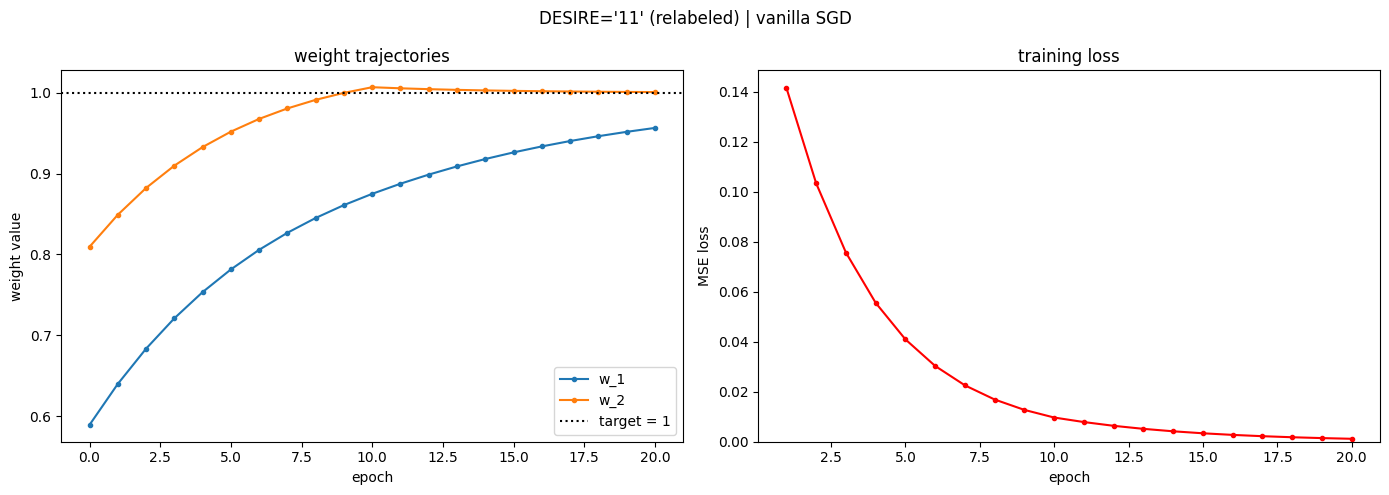

In [11]:
result_11 = training(
    desire='11',
    csv_path='/content/thesis-edit-distance-nn/sampledata/desired_length_2_levenshtein_relabel_11.csv',
    epochs=20,
    learning_rate=0.1,
    seed=42,
)
plot_training(result_11, title="DESIRE='11' (relabeled) | vanilla SGD")

## Experiment 2 — DESIRE='21' (relabeled from '01')

**This is the headline test.** With the original `{0, 1}` alphabet and target `'01'`, vanilla SGD got stuck because `w_1` had a structurally zero gradient (`y[0] = 0`). After relabeling, `y[0] = 2`, so the gradient factor becomes `2` and the weight should converge to `1` cleanly.

=== training data ===
  21,21,0
  12,21,2
  11,21,1
  22,21,1
setting frozen weights ...
freezing all non-trainable layers ...
init weights: [0.5892657041549683, 0.8094304800033569]
epoch   0 | batch_loss = 0.692969 | weights = [0.9178531169891357, 0.8284874558448792]
epoch   1 | batch_loss = 0.041701 | weights = [0.9835706353187561, 0.8456386923789978]
epoch   2 | batch_loss = 0.012993 | weights = [0.9967141151428223, 0.8610748052597046]
epoch   3 | batch_loss = 0.009693 | weights = [0.9993427991867065, 0.8749673366546631]
epoch   4 | batch_loss = 0.007818 | weights = [0.9998685717582703, 0.8874706029891968]
epoch   5 | batch_loss = 0.006332 | weights = [0.999973714351654, 0.8987235426902771]
epoch   6 | batch_loss = 0.005128 | weights = [0.9999947547912598, 0.9088512063026428]
epoch   7 | batch_loss = 0.004154 | weights = [0.999998927116394, 0.9179660677909851]
epoch   8 | batch_loss = 0.003365 | weights = [0.9999997615814209, 0.9261694550514221]
epoch   9 | batch_loss = 0.002725 | w

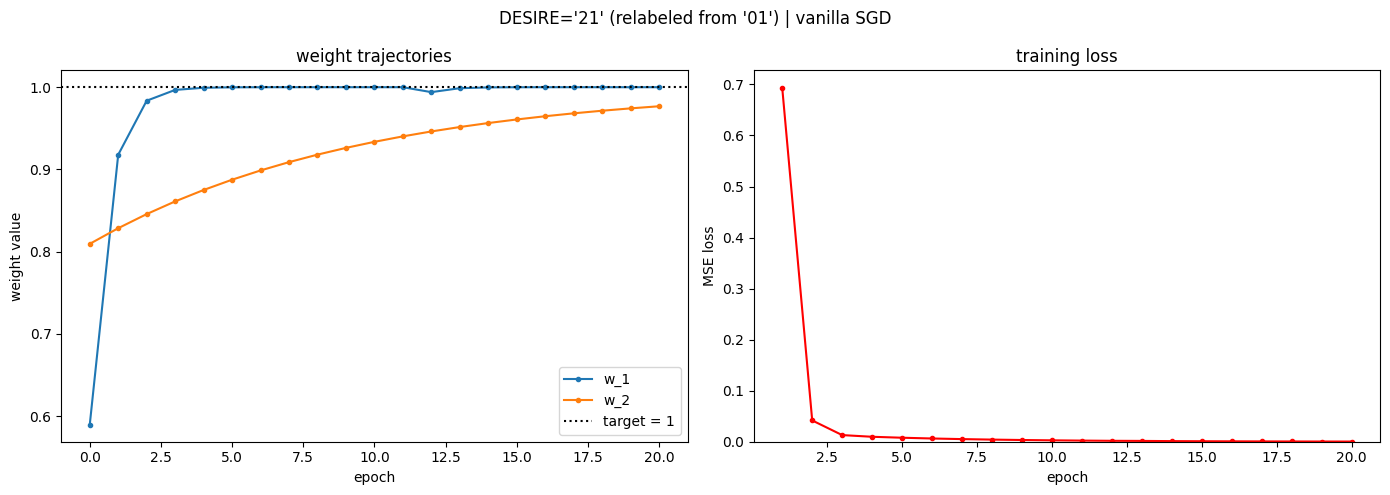

In [12]:
result_21 = training(
    desire='21',
    csv_path='/content/thesis-edit-distance-nn/sampledata/desired_length_2_levenshtein_relabel_21.csv',
    epochs=20,
    learning_rate=0.1,
    seed=42,
)
plot_training(result_21, title="DESIRE='21' (relabeled from '01') | vanilla SGD")

## Experiment 3 — DESIRE='21211' (relabeled from '01011')

**The hard case.** Under the original `{0, 1}` encoding with target `'01011'`:

- Two weights had structurally dead gradients (`w_1` and `w_3`, where `y[i] = 0`)
- The loss landscape had a 2D flat plane of degenerate global minima
- PSO + binary regularization eventually found `[1, 1, 1, 1, 1]` after ~2 hours, but it was just one of four equally-valid corners — not actually the 'true' `[0, 1, 0, 1, 1]` we naively expected

Under the relabeled `{1, 2}` encoding, target `'21211'` should be a clean single-minimum problem:

- Every `y[i] != 0`, so every weight has a nonzero gradient factor
- The unique global minimum is `[1, 1, 1, 1, 1]` (forward correctness pins each `w_i` to 1)
- Vanilla SGD should converge in a small number of epochs

Note the predicted convergence-rate asymmetry: positions where `y[i] = 2` (positions 0, 2) have gradient factor `2`, so they should converge faster than positions where `y[i] = 1` (positions 1, 3, 4) which have gradient factor `1`.

=== training data ===
  22222,21211,3
  22221,21211,2
  22212,21211,2
  22211,21211,1
  22122,21211,3
  22121,21211,2
  22112,21211,2
  22111,21211,2
  21222,21211,2
  21221,21211,1
  21212,21211,1
  21211,21211,0
  21122,21211,3
  21121,21211,2
  21112,21211,2
  21111,21211,1
  12222,21211,4
  12221,21211,3
  12212,21211,3
  12211,21211,2
  12122,21211,3
  12121,21211,2
  12112,21211,2
  12111,21211,2
  11222,21211,3
  11221,21211,2
  11212,21211,2
  11211,21211,1
  11122,21211,4
  11121,21211,3
  11112,21211,3
  11111,21211,2
setting frozen weights ...
freezing all non-trainable layers ...
init weights: [0.4537236988544464, 0.9538159370422363, 0.8758529424667358, 0.26338905096054077, 0.5005860924720764]
epoch   0 | batch_loss = 1.872222 | weights = [0.5025199055671692, 1.0714735984802246, 1.1240204572677612, 0.37809091806411743, 0.6205772757530212]
epoch   1 | batch_loss = 1.627485 | weights = [0.7781895399093628, 1.051247239112854, 0.8680572509765625, 0.49247652292251587, 0.73621958

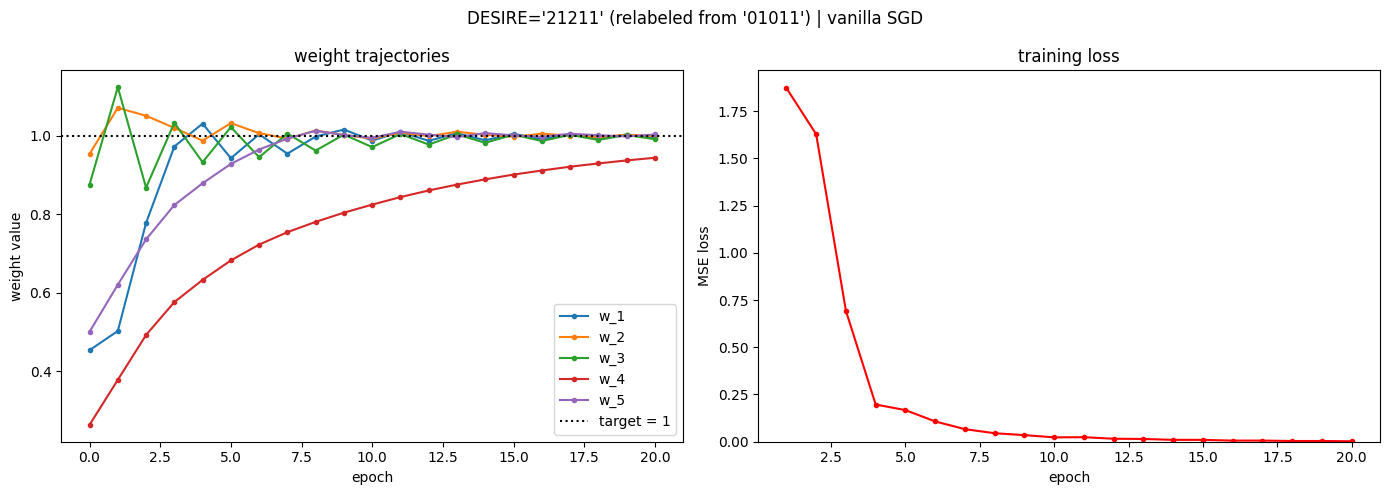

In [13]:
result_21211 = training(
    desire='21211',
    csv_path='/content/thesis-edit-distance-nn/sampledata/desired_length_5_levenshtein_relabel_21211.csv',
    epochs=20,
    learning_rate=0.1,
    seed=42,
)
plot_training(result_21211, title="DESIRE='21211' (relabeled from '01011') | vanilla SGD")

## What to look for

1. **All three runs should converge to `[1, 1, ...]`** — every weight near 1.0, regardless of which character (`1` or `2`) appears at that position of the target.
2. **Loss should drop to ~0** within a small number of epochs in all three cases.
3. **No weight should remain stuck at its random initialization** — especially `w_1` in experiment 2, and `w_1` and `w_3` in experiment 3, which were the structurally dead positions under the original `{0, 1}` encoding.
4. **Convergence rate asymmetry** — positions where `y[i] = 2` should converge faster than positions where `y[i] = 1`, because the gradient factor is `2` vs `1`. This is a free byproduct of relabeling: the previously dead dimensions are now the *fastest* to learn.

If experiment 3 converges in 20 epochs of vanilla SGD, that's the strongest possible refutation of the paper's 'local solution problem'. Both pathologies — the dead gradient *and* the four-corner ambiguity that PSO had to navigate — vanish at once with a one-line preprocessing change.